### LÄSA IN DATA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

### BYGG SÄSONGSBASERAD DATASET (senaste säsong per spelare)

In [ ]:
import os
import pandas as pd
from pymongo import MongoClient
from dotenv import load_dotenv


# LÄSA IN KAGGLE-DATAN
# Läs CSV filer

players = pd.read_csv("players.csv")
apps = pd.read_csv("appearances.csv")
games = pd.read_csv("games.csv")


#  LÄGG TILL SÄSONG PÅ VARJE APPEARANCE

apps = apps.merge(
    games[["game_id", "season"]],
    on="game_id",
    how="left"
)

# SUMMERA STATS PER SPELARE + SÄSONG

season_stats = (
    apps.groupby(["player_id", "season"])[
        ["goals", "assists", "minutes_played"]
    ]
    .sum()
    .reset_index()
)

# HITTA SENASTE SÄSONGEN FÖR VARJE SPELARE

latest_season = (
    season_stats
    .sort_values("season")
    .groupby("player_id")
    .tail(1)
)

# Ta bara med spelare vars senaste säsong är efter 2020
latest_season = latest_season[latest_season["season"] > 2020]


# SLÅ IHOP MED PLAYER-INFORMATION

df = players.merge(
    latest_season,
    on="player_id",
    how="inner"
)

# SKAPA AGE

df["date_of_birth"] = pd.to_datetime(
    df["date_of_birth"],
    errors="coerce"
)

# Räknar ålder utifrån säsongen spelaren hade dessa stats
# annars blir åldern fel för spelare vars senaste säsong ligger flera år tillbaka
df["age"] = df["season"] - df["date_of_birth"].dt.year


# VÄLJ ENDAST FEATURES + TARGET

features = [
    "position",
    "age",
    "goals",
    "assists",
    "minutes_played",
    "current_club_domestic_competition_id"
]

target = "market_value_in_eur"

df_final = df[features + [target]].copy()

# Ta bort spelare utan target eller utan age
df_final = df_final.dropna(subset=[target, "age"])

print(df_final.head())


load_dotenv()

mongo_uri = os.getenv("MONGODB_URI")

client = MongoClient(mongo_uri)

db = client["football_data"]

new_collection = db["players_data_season"]

records = df_final.to_dict("records")

new_collection.delete_many({})
new_collection.insert_many(records)

print(
    f"{new_collection.count_documents({})} spelare sparade i MongoDB"
)

     position   age  goals  assists  minutes_played  \
0    Midfield  39.0      1        1             946   
1      Attack  41.0      1        0             144   
2  Goalkeeper  38.0      0        0              90   
3      Attack  38.0      2        1            1005   
4  Goalkeeper  39.0      0        0             720   

  current_club_domestic_competition_id  market_value_in_eur  
0                                  GB1             500000.0  
1                                  IT1            2000000.0  
2                                  DK1             100000.0  
3                                  PO1             300000.0  
4                                  NL1              75000.0  
15306 spelare sparade i MongoDB


In [3]:
import os
import pandas as pd
from dotenv import load_dotenv
from pymongo import MongoClient

# 1. Läs in miljövariabler från .env
load_dotenv()
mongo_uri = os.getenv("MONGODB_URI")

if not mongo_uri:
    raise ValueError("Kunde inte hitta MONGO_URI. Kontrollera att .env-filen finns och innehåller rätt variabel.")

# 2. Koppla upp mot MongoDB Atlas
client = MongoClient(mongo_uri)
db = client["football_data"]
collection = db["players_data_season"]

# 3. Hämta alla dokument och uteslut _id
data = list(collection.find({}, {"_id": 0}))

# 4. Gör om till DataFrame
df_from_db = pd.DataFrame(data)

# 5. Bygg X och y
target = 'market_value_in_eur'
y = df_from_db[target]
X_features = df_from_db.drop(columns=[target])

X = pd.get_dummies(X_features, drop_first=True)

print(df_from_db.shape)

(15306, 7)


### EDA

In [ ]:
# Snittvärdet på alla spelare
print(y.mean())

3432710.7016856135


In [5]:
# Kollar om det saknas värden nånstans innan vi kör modellen
print("Antal NaN per kolumn:")
print(X.isna().sum())

Antal NaN per kolumn:
age                                          0
goals                                        0
assists                                      0
minutes_played                               0
position_Defender                            0
position_Goalkeeper                          0
position_Midfield                            0
position_Missing                             0
current_club_domestic_competition_id_ARG1    0
current_club_domestic_competition_id_AUS1    0
current_club_domestic_competition_id_BE1     0
current_club_domestic_competition_id_BRA1    0
current_club_domestic_competition_id_C1      0
current_club_domestic_competition_id_COL1    0
current_club_domestic_competition_id_DK1     0
current_club_domestic_competition_id_ES1     0
current_club_domestic_competition_id_FR1     0
current_club_domestic_competition_id_GB1     0
current_club_domestic_competition_id_GR1     0
current_club_domestic_competition_id_IT1     0
current_club_domestic_competition_id_J

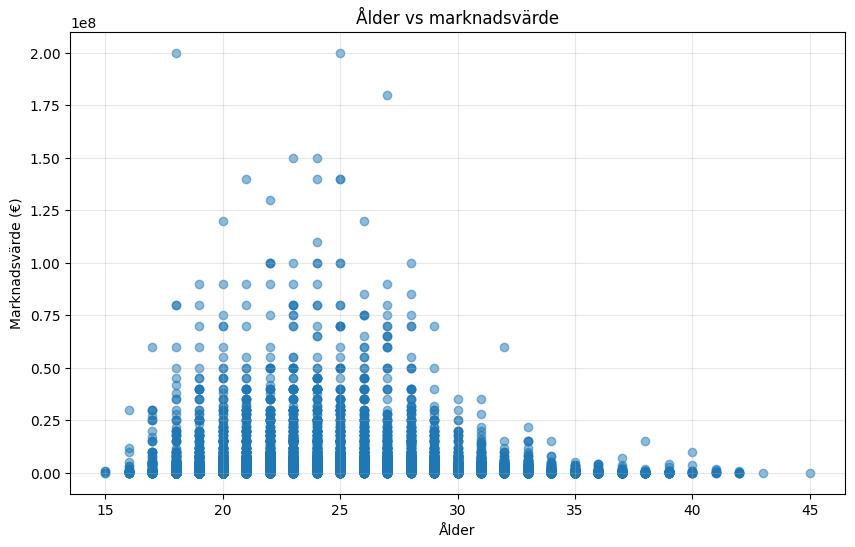

In [ ]:
# Kollar snabbt om det finnas nåt samband mellan ålder och marknadsvärde
plt.figure(figsize=(10, 6))

plt.scatter(
    df_from_db["age"],
    df_from_db["market_value_in_eur"],
    alpha=0.5
)

plt.xlabel("Ålder")
plt.ylabel("Marknadsvärde (€)")
plt.title("Ålder vs marknadsvärde")

plt.grid(alpha=0.3)
plt.show()

### TRÄNA / TESTA

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Delar upp datan i tre delar: train (60%), val (20%), test (20%)
X_train_full, X_test, y_train_full, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25, random_state=42)

y_train_log = np.log1p(y_train)

# Testar en massa olika kombinationer av hyperparametrar för att hitta bästa Random Forest
hyper_params = {
    'max_depth': [None, 5, 10, 20, 30],
    'n_estimators': [50, 100, 150],
    'min_samples_split': [2, 5, 10]
}
clf = RandomForestRegressor(random_state=42)
gs = GridSearchCV(estimator=clf, param_grid=hyper_params, cv=2, n_jobs=-1, verbose=2)
gs.fit(X_train, y_train_log)
print("Bästa parametrar:", gs.best_params_) 

# Jämför modellerna mot varandra
models = {
    "BaseLine" : DummyRegressor(strategy='mean'),
    'Linjär Regression' : LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    "Random Forest (Tuned)": gs.best_estimator_
}


for name, model in models.items():
    if name != "Random Forest (Tuned)":
        model.fit(X_train, y_train_log)

    # Prediktera och konvertera tillbaka till vanliga euro
    log_preds = model.predict(X_val)
    preds = np.expm1(log_preds)

    rmse = np.sqrt(mean_squared_error(y_val, preds))
    r2 = r2_score(y_val, preds)

    print(f'{name:20} | {rmse:12,.0f} € | {r2:6.3f}')


Fitting 2 folds for each of 45 candidates, totalling 90 fits
Bästa parametrar: {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 150}
BaseLine             |   10,128,609 € | -0.068
Linjär Regression    |   37,666,871 € | -13.775
Random Forest        |    5,968,433 € |  0.629
Random Forest (Tuned) |    6,024,212 € |  0.622


In [ ]:
# Extra koll efter träningen, ska fortfarande vara noll NaN här
print("Antal NaN per kolumn:")
print(X.isna().sum())

Antal NaN per kolumn:
age                                          0
goals                                        0
assists                                      0
minutes_played                               0
position_Defender                            0
position_Goalkeeper                          0
position_Midfield                            0
position_Missing                             0
current_club_domestic_competition_id_ARG1    0
current_club_domestic_competition_id_AUS1    0
current_club_domestic_competition_id_BE1     0
current_club_domestic_competition_id_BRA1    0
current_club_domestic_competition_id_C1      0
current_club_domestic_competition_id_COL1    0
current_club_domestic_competition_id_DK1     0
current_club_domestic_competition_id_ES1     0
current_club_domestic_competition_id_FR1     0
current_club_domestic_competition_id_GB1     0
current_club_domestic_competition_id_GR1     0
current_club_domestic_competition_id_IT1     0
current_club_domestic_competition_id_J

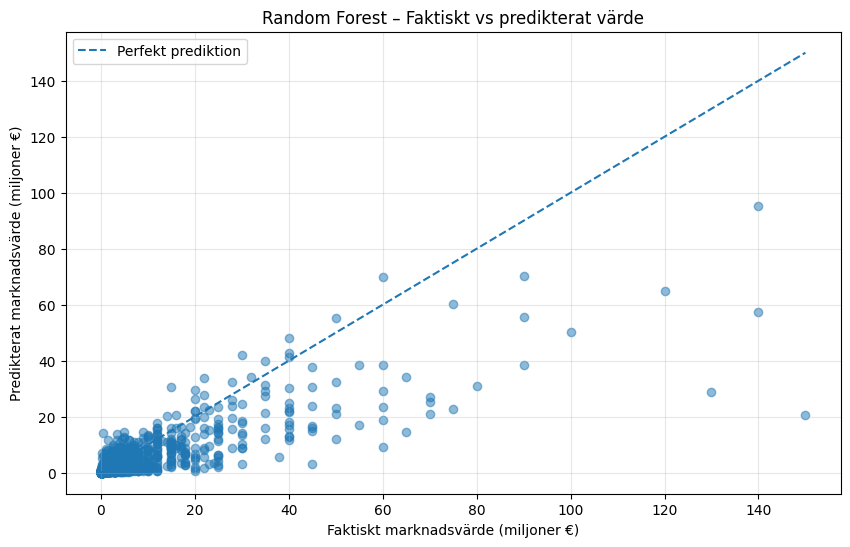

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Välj modellen
model = models["Random Forest (Tuned)"]

# Scatterplot
plt.figure(figsize=(10, 6))

plt.scatter(
    y_val / 1_000_000,
    preds / 1_000_000,
    alpha=0.5
)

# Perfekt prediktion: y = x
min_value = min(y_val.min(), preds.min()) / 1_000_000
max_value = max(y_val.max(), preds.max()) / 1_000_000

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Perfekt prediktion"
)

plt.xlabel("Faktiskt marknadsvärde (miljoner €)")
plt.ylabel("Predikterat marknadsvärde (miljoner €)")
plt.title("Random Forest – Faktiskt vs predikterat värde")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [10]:
# Träna om bästa modellen på HELA träningsdatan (train + val) innan slutgiltigt test
y_train_full_log = np.log1p(y_train_full)

final_model = RandomForestRegressor(**gs.best_params_, random_state=42)
final_model.fit(X_train_full, y_train_full_log)

test_pred_log = final_model.predict(X_test)
test_pred = np.expm1(test_pred_log)

final_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
final_r2 = r2_score(y_test, test_pred)

print('RMSE = ', final_rmse)
print('R2 = ', final_r2)


RMSE =  5410145.446346937
R2 =  0.6149785565589083


### SPARA

In [11]:
import joblib

# Sparar den slutgiltiga modellen (omtränad på X_train_full = train + val)
modell = joblib.dump(final_model, "rfr_tuned.pkl")

rfr = joblib.load("rfr_tuned.pkl")

print(type(rfr))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [ ]:
import numpy as np
import pandas as pd

# Skapa en tom rad med exakt samma kolumnnamn som träningsdatan
calle = pd.DataFrame(0, index=[0], columns=X_train_full.columns)

# Fyll i siffervärden
calle['age'] = 25
calle['goals'] = 27
calle['assists'] = 8
calle['minutes_played'] = 3590  # t.ex. en hel säsong som ordinarie

# Sätt en 1:a på hans position (Anfallare / Attack)
for col in calle.columns:
    if 'position' in col and 'Attack' in col:
        calle[col] = 1

for col in calle.columns:
    if 'GB1' in col:
        calle[col] = 1

# 5. Låt modellen gissa 
# Omvandlar från log-skala med expm1
calle_log_pred = final_model.predict(calle)
calle_varde = np.expm1(calle_log_pred)[0]

print(f"Spelare: Calle Pålsson")
print(f"Stats:   27 mål, 8 assist, Premier leauge")
print(f"Uppskattat marknadsvärde: {calle_varde:,.0f} €")

Spelare: Calle Pålsson
Stats:   27 mål, 8 assist, Premier leauge
Uppskattat marknadsvärde: 51,967,389 €
